In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\07_seleccion_entrenar_modelo\3_entrenar_modelo_arimax\5_con_rezagos_son_escalado_con_reduccion_spierman_aicc_con_validacion_cruzada\2_datos\1_raw\meteo_completos_epi_con_rezagos_sin_reduccion.xlsx"

print("[INFO] Cargando datos desde Excel...")
df = pd.read_excel(ruta_datos)
df


[INFO] Cargando datos desde Excel...


,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,soi_lag_8,soi_lag_9,soi_lag_10,soi_lag_11,soi_lag_12,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,9.348571,15.430000,10.847143,18.207143,20.067143,-0.897892,-0.837360,-0.931407,-1.058352,-1.060214
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,16.120000,9.348571,15.430000,10.847143,18.207143,-0.977896,-0.897892,-0.837360,-0.931407,-1.058352
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,18.705714,16.120000,9.348571,15.430000,10.847143,-0.803088,-0.977896,-0.897892,-0.837360,-0.931407
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,2.744286,18.705714,16.120000,9.348571,15.430000,-1.097763,-0.803088,-0.977896,-0.897892,-0.837360
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,-6.417143,2.744286,18.705714,16.120000,9.348571,-0.838514,-1.097763,-0.803088,-0.977896,-0.897892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,2025-11-30,2025,49,25.527143,28.834286,23.218571,18.514286,90.482857,27.53,6,...,12.264286,1.620000,2.591429,-0.221429,-4.208571,-0.268223,-0.346037,-0.454914,-0.329364,-0.353051
245,2025-12-07,2025,50,26.065714,29.091429,23.882857,19.224286,90.717143,21.56,4,...,2.555714,12.264286,1.620000,2.591429,-0.221429,-0.366160,-0.268223,-0.346037,-0.454914,-0.329364
246,2025-12-14,2025,51,26.038571,29.442857,23.658571,18.982857,89.951429,30.71,6,...,16.565714,2.555714,12.264286,1.620000,2.591429,-0.436933,-0.366160,-0.268223,-0.346037,-0.454914
247,2025-12-21,2025,52,25.997143,30.090000,23.008571,17.992857,85.818571,2.49,1,...,17.272857,16.565714,2.555714,12.264286,1.620000,-0.461052,-0.436933,-0.366160,-0.268223,-0.346037


In [3]:

# =============================================================================
# PASO 2: REDUCCIÓN DIMENSIONAL POR SPEARMAN (OPTIMIZADA)
# =============================================================================
print("\n[INFO] Ejecutando reducción dimensional con Spearman...")
columnas_excluir = ['casos_dengue', 'casos_ln', 'fecha', 'semana_epi', 'año']
variables_meteo = [col for col in df.columns if col not in columnas_excluir]
variables_meteo, len(variables_meteo)


[INFO] Ejecutando reducción dimensional con Spearman...


(['temp',
  'temp_max',
  'temp_min',
  'hum_esp',
  'hum_rel',
  'prec',
  'dias_lluvia',
  'vel_vi',
  'vel_vi_max',
  'vel_vi_min',
  'uv',
  'soi',
  'sst',
  'temp_lag_1',
  'temp_lag_2',
  'temp_lag_3',
  'temp_lag_4',
  'temp_lag_5',
  'temp_lag_6',
  'temp_lag_7',
  'temp_lag_8',
  'temp_max_lag_1',
  'temp_max_lag_2',
  'temp_max_lag_3',
  'temp_max_lag_4',
  'temp_max_lag_5',
  'temp_max_lag_6',
  'temp_max_lag_7',
  'temp_max_lag_8',
  'temp_min_lag_1',
  'temp_min_lag_2',
  'temp_min_lag_3',
  'temp_min_lag_4',
  'temp_min_lag_5',
  'temp_min_lag_6',
  'temp_min_lag_7',
  'temp_min_lag_8',
  'hum_esp_lag_1',
  'hum_esp_lag_2',
  'hum_esp_lag_3',
  'hum_esp_lag_4',
  'hum_esp_lag_5',
  'hum_esp_lag_6',
  'hum_esp_lag_7',
  'hum_esp_lag_8',
  'hum_rel_lag_1',
  'hum_rel_lag_2',
  'hum_rel_lag_3',
  'hum_rel_lag_4',
  'hum_rel_lag_5',
  'hum_rel_lag_6',
  'hum_rel_lag_7',
  'hum_rel_lag_8',
  'prec_lag_1',
  'prec_lag_2',
  'prec_lag_3',
  'prec_lag_4',
  'prec_lag_5',
  'prec

In [5]:

matriz_corr = df[variables_meteo + ['casos_dengue']].corr(method='spearman')
corr_con_objetivo = matriz_corr['casos_dengue'].drop('casos_dengue').abs()
corr_con_objetivo 

temp          0.206866
temp_max      0.265372
temp_min      0.039238
hum_esp       0.510743
hum_rel       0.402911
                ...   
sst_lag_8     0.436458
sst_lag_9     0.449064
sst_lag_10    0.469661
sst_lag_11    0.475646
sst_lag_12    0.479574
Name: casos_dengue, Length: 111, dtype: float64

In [12]:

# Selección del Top de variables correlacionadas (Ajustado a percentil 0.30 como tenías)
umbral_target = corr_con_objetivo.quantile(0.30) 
umbral_target 

np.float64(0.24753961682129058)

In [13]:
variables_candidatas = corr_con_objetivo[corr_con_objetivo >= umbral_target].index.tolist()
variables_candidatas, len(variables_candidatas)

(['temp_max',
  'hum_esp',
  'hum_rel',
  'prec',
  'dias_lluvia',
  'vel_vi',
  'vel_vi_max',
  'sst',
  'temp_lag_5',
  'temp_lag_7',
  'temp_lag_8',
  'temp_max_lag_1',
  'temp_max_lag_2',
  'temp_max_lag_3',
  'temp_max_lag_4',
  'temp_max_lag_5',
  'temp_max_lag_6',
  'temp_max_lag_7',
  'temp_max_lag_8',
  'hum_esp_lag_1',
  'hum_esp_lag_2',
  'hum_esp_lag_3',
  'hum_esp_lag_4',
  'hum_esp_lag_5',
  'hum_esp_lag_6',
  'hum_esp_lag_7',
  'hum_esp_lag_8',
  'hum_rel_lag_1',
  'hum_rel_lag_2',
  'hum_rel_lag_3',
  'hum_rel_lag_4',
  'hum_rel_lag_5',
  'hum_rel_lag_6',
  'hum_rel_lag_7',
  'hum_rel_lag_8',
  'prec_lag_1',
  'prec_lag_2',
  'prec_lag_3',
  'prec_lag_4',
  'prec_lag_5',
  'prec_lag_6',
  'prec_lag_7',
  'prec_lag_8',
  'dias_lluvia_lag_1',
  'dias_lluvia_lag_2',
  'dias_lluvia_lag_3',
  'dias_lluvia_lag_4',
  'dias_lluvia_lag_5',
  'dias_lluvia_lag_6',
  'dias_lluvia_lag_7',
  'dias_lluvia_lag_8',
  'vel_vi_lag_1',
  'vel_vi_lag_2',
  'vel_vi_lag_3',
  'vel_vi_lag_4',


In [14]:

# RECOMENDACIÓN CONTROL MULTICOLINEALIDAD: Umbral fijo estricto (0.55) para evitar redundancia climática
sub_matriz_interna = df[variables_candidatas].corr(method='spearman').abs()
umbral_inter_corr = 0.55  

variables_seleccionadas = []
variables_ordenadas = corr_con_objetivo[variables_candidatas].sort_values(ascending=False).index.tolist()

for var in variables_ordenadas:
    admitir = True
    for var_aceptada in variables_seleccionadas:
        if sub_matriz_interna.loc[var, var_aceptada] > umbral_inter_corr:
            admitir = False
            break
    if admitir:
        variables_seleccionadas.append(var)

print(f" -> Variables meteorológicas exógenas seleccionadas ({len(variables_seleccionadas)}): {variables_seleccionadas}")


 -> Variables meteorológicas exógenas seleccionadas (9): ['hum_esp_lag_6', 'sst_lag_12', 'dias_lluvia_lag_5', 'dias_lluvia_lag_3', 'vel_vi_max_lag_8', 'dias_lluvia_lag_1', 'soi_lag_11', 'uv_lag_8', 'soi_lag_8']


In [30]:
df = df[['fecha', 'semana_epi', 'año', 'casos_dengue'] + variables_seleccionadas]
df.index = pd.to_datetime(df['fecha'])
df.head()

,fecha,semana_epi,año,casos_dengue,hum_esp_lag_6,sst_lag_12,dias_lluvia_lag_5,dias_lluvia_lag_3,vel_vi_max_lag_8,dias_lluvia_lag_1,soi_lag_11,uv_lag_8,soi_lag_8
fecha,,,,,,,,,,,,,
2021-03-28,2021-03-28,13,2021,1,16.551429,-1.060214,0,0,0.225714,0,18.207143,2.290000,9.348571
2021-04-04,2021-04-04,14,2021,0,16.070000,-1.058352,2,0,0.280000,0,10.847143,2.144286,16.120000
2021-04-11,2021-04-11,15,2021,0,15.074286,-0.931407,0,0,0.244286,2,15.430000,2.355714,18.705714
2021-04-18,2021-04-18,16,2021,0,15.761429,-0.837360,0,0,0.258571,5,9.348571,2.122857,2.744286
2021-04-25,2021-04-25,17,2021,0,15.995714,-0.897892,0,2,0.262857,1,16.120000,2.155714,-6.417143


In [31]:
X_features = df[variables_seleccionadas]
y = df['casos_dengue']

In [32]:
X_features.head()

,hum_esp_lag_6,sst_lag_12,dias_lluvia_lag_5,dias_lluvia_lag_3,vel_vi_max_lag_8,dias_lluvia_lag_1,soi_lag_11,uv_lag_8,soi_lag_8
fecha,,,,,,,,,
2021-03-28,16.551429,-1.060214,0,0,0.225714,0,18.207143,2.290000,9.348571
2021-04-04,16.070000,-1.058352,2,0,0.280000,0,10.847143,2.144286,16.120000
2021-04-11,15.074286,-0.931407,0,0,0.244286,2,15.430000,2.355714,18.705714
2021-04-18,15.761429,-0.837360,0,0,0.258571,5,9.348571,2.122857,2.744286
2021-04-25,15.995714,-0.897892,0,2,0.262857,1,16.120000,2.155714,-6.417143



 INICIANDO VALIDACIÓN CRUZADA ANUAL (4 FOLDS DETECTADOS)
 Años de entrenamiento encontrados: [2021, 2022, 2023, 2024]

[PROCESANDO] Fold 1 (Train: 2021 -> Test: Q1 2022)...
   -> Entrenamiento (Train) : 40 semanas | Desde 2021-03-28 hasta 2021-12-26
   -> Pronóstico (Test)     : 13 semanas | Desde 2022-01-02 hasta 2022-03-27


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


   -> [ÉXITO] MAE Train: 1.6695 | MAE Test: 3.5070

[PROCESANDO] Fold 2 (Train: 2022 -> Test: Q1 2023)...
   -> Entrenamiento (Train) : 52 semanas | Desde 2022-01-02 hasta 2022-12-25
   -> Pronóstico (Test)     : 13 semanas | Desde 2023-01-01 hasta 2023-03-26


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


   -> [ÉXITO] MAE Train: 3.5779 | MAE Test: 11.1358

[PROCESANDO] Fold 3 (Train: 2023 -> Test: Q1 2024)...
   -> Entrenamiento (Train) : 53 semanas | Desde 2023-01-01 hasta 2023-12-31
   -> Pronóstico (Test)     : 13 semanas | Desde 2024-01-07 hasta 2024-03-31


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


   -> [ÉXITO] MAE Train: 5.4127 | MAE Test: 11.6666

[PROCESANDO] Fold 4 (Train: 2024 -> Test: Q1 2025)...
   -> Entrenamiento (Train) : 52 semanas | Desde 2024-01-07 hasta 2024-12-29
   -> Pronóstico (Test)     : 13 semanas | Desde 2025-01-05 hasta 2025-03-30


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


   -> [ÉXITO] MAE Train: 9.9955 | MAE Test: 24.7424


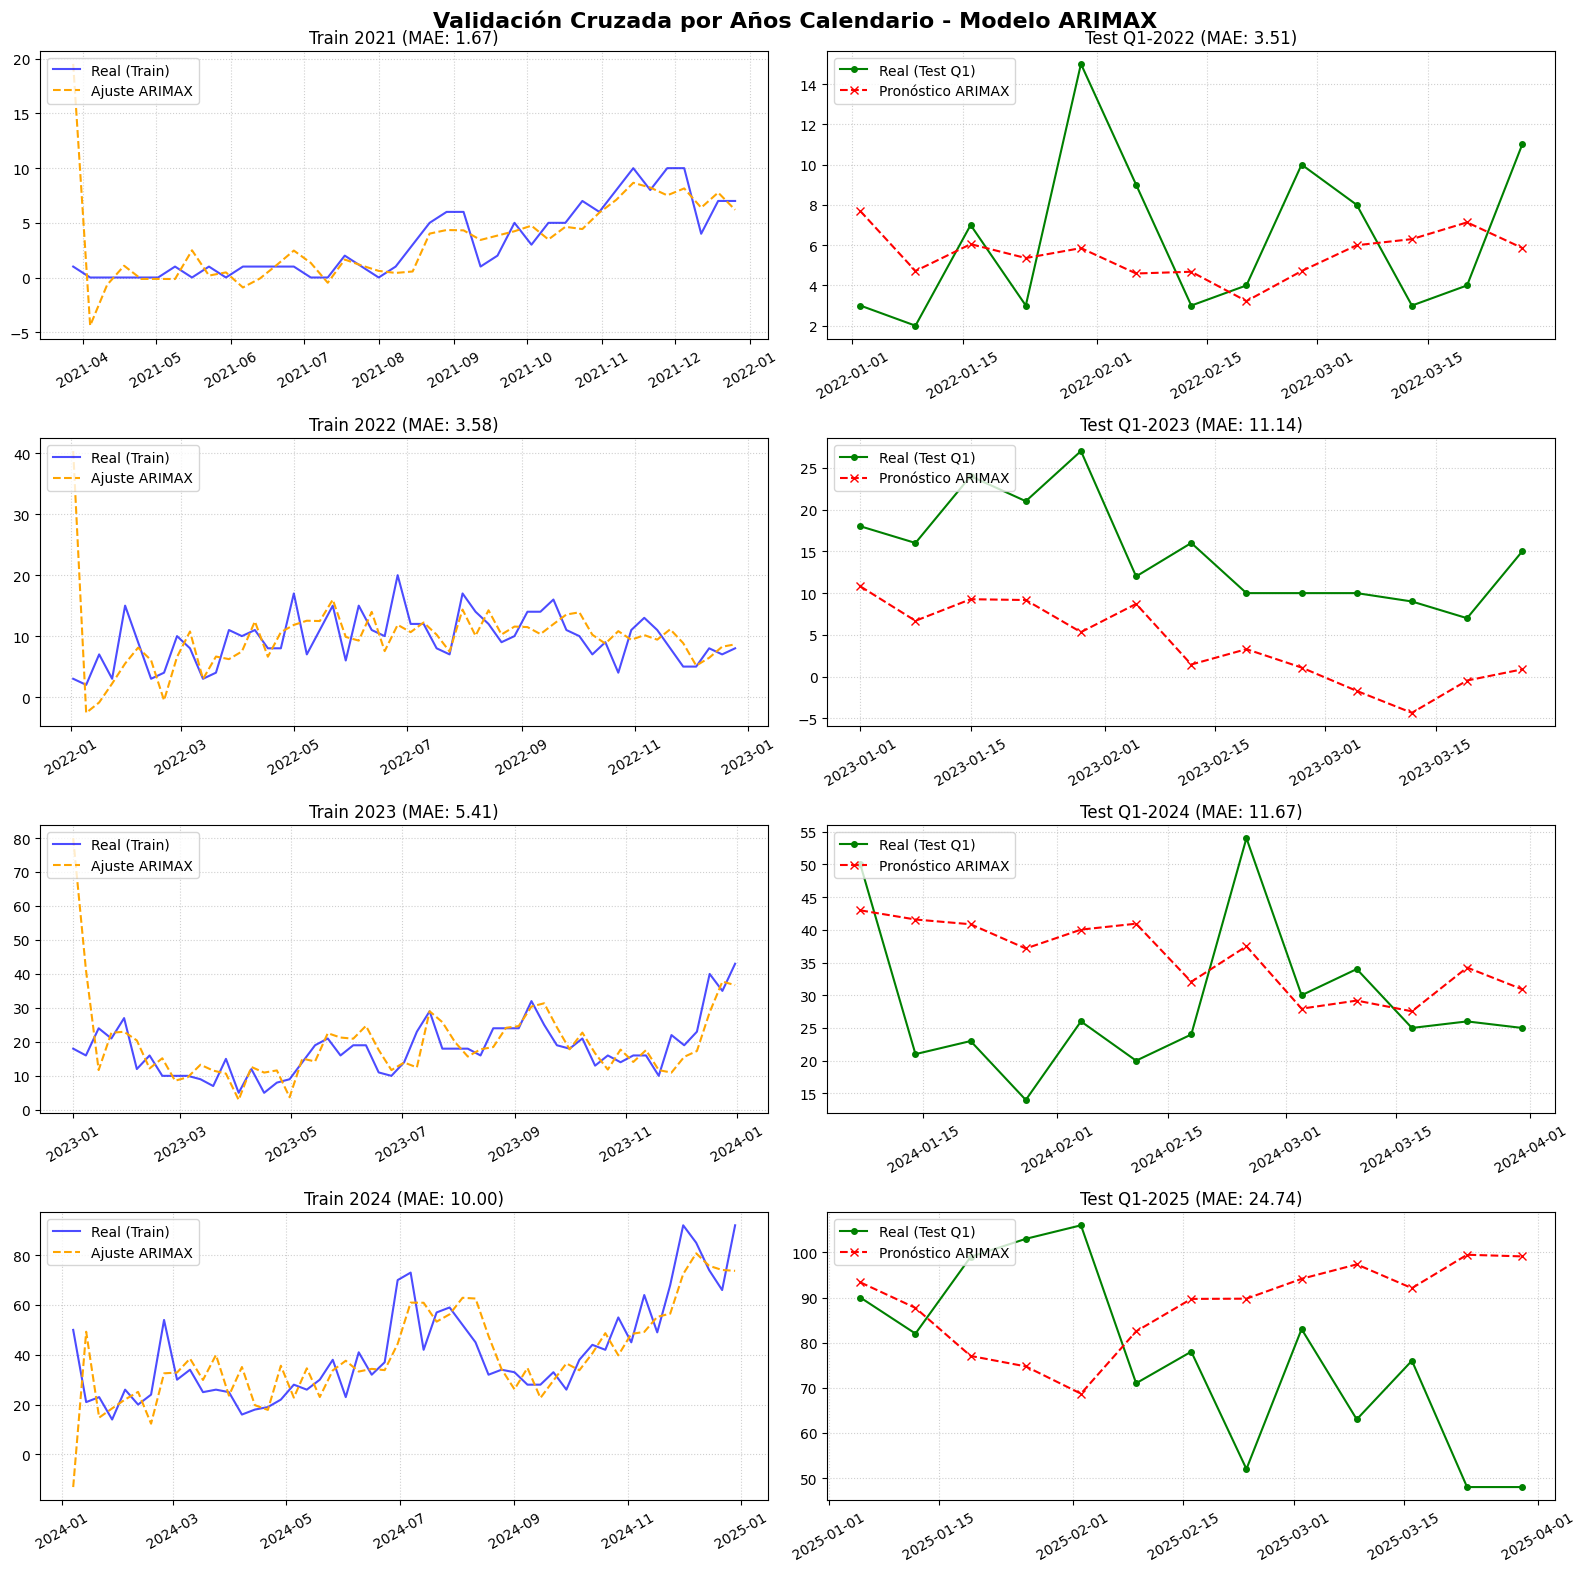


 RESUMEN FINAL DE LA VALIDACIÓN CRUZADA CALENDARIO
    Fold Algoritmo  Variables X Train Inicio  Train Fin Test Inicio   Test Fin  MAE Train  MAE Test
Año 2021    ARIMAX            9   2021-03-28 2021-12-26  2022-01-02 2022-03-27   1.669459  3.506991
Año 2022    ARIMAX            9   2022-01-02 2022-12-25  2023-01-01 2023-03-26   3.577947 11.135825
Año 2023    ARIMAX            9   2023-01-01 2023-12-31  2024-01-07 2024-03-31   5.412652 11.666590
Año 2024    ARIMAX            9   2024-01-07 2024-12-29  2025-01-05 2025-03-30   9.995502 24.742363


In [33]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# =============================================================================
# CORRECCIÓN CRÍTICA 1: Forzar formato de fecha para evitar años erróneos
# =============================================================================
# 'dayfirst=True' le avisa a Pandas que si ve "05/12/2021", el 05 es el día y no el mes/año.
y.index = pd.to_datetime(y.index, dayfirst=True, errors='coerce')
X_features.index = pd.to_datetime(X_features.index, dayfirst=True, errors='coerce')

# =============================================================================
# CORRECCIÓN CRÍTICA 2: Auto-detectar los años reales en tu Dataset
# =============================================================================
# En lugar de escribir [2021, 2022...], dejamos que Python extraiga los años que sí existen.
anos_disponibles = sorted(y.index.year.dropna().unique())

# Filtramos el último año porque no tendrá un "año siguiente" completo para testear en Q1
ANOS_ENTRENAMIENTO = [ano for ano in anos_disponibles if (ano + 1) in anos_disponibles]
N_SPLITS = len(ANOS_ENTRENAMIENTO)

if N_SPLITS == 0:
    print("\n" + "!"*75)
    print(f" ERROR CRÍTICO: Los años detectados en tu índice son: {anos_disponibles}")
    print(" No se pueden generar cortes. Revisa el formato de origen de tus fechas.")
    print("!"*75)
else:
    # Creamos la grilla dinámicamente según los splits reales encontrados
    fig, axes = plt.subplots(nrows=N_SPLITS, ncols=2, figsize=(16, 4 * N_SPLITS), sharex=False, sharey=False)
    fig.suptitle("Validación Cruzada por Años Calendario - Modelo ARIMAX", fontsize=16, fontweight='bold', y=0.98)

    resultados_globales = []

    print("\n" + "="*85)
    print(f" INICIANDO VALIDACIÓN CRUZADA ANUAL ({N_SPLITS} FOLDS DETECTADOS)")
    print(f" Años de entrenamiento encontrados: {ANOS_ENTRENAMIENTO}")
    print("="*85)

    for idx, ano in enumerate(ANOS_ENTRENAMIENTO):
        nombre_split = f"Fold {idx + 1} (Train: {ano} -> Test: Q1 {ano+1})"
        print(f"\n[PROCESANDO] {nombre_split}...")
        
        ano_test = ano + 1
        
        # Filtrado directo
        y_train = y[y.index.year == ano]
        X_train = X_features[X_features.index.year == ano]
        
        y_test = y[(y.index.year == ano_test) & (y.index.month.isin([1, 2, 3]))]
        X_test = X_features[(X_features.index.year == ano_test) & (X_features.index.month.isin([1, 2, 3]))]

        if len(y_train) == 0 or len(y_test) == 0:
            print(f"   [AVISO] Saltando {nombre_split}: Faltan datos en Train ({len(y_train)} sem) o Test ({len(y_test)} sem).")
            continue
            
        fecha_init_train = y_train.index[0].strftime('%Y-%m-%d')
        fecha_end_train  = y_train.index[-1].strftime('%Y-%m-%d')
        fecha_init_test  = y_test.index[0].strftime('%Y-%m-%d')
        fecha_end_test   = y_test.index[-1].strftime('%Y-%m-%d')
        
        print(f"   -> Entrenamiento (Train) : {len(y_train)} semanas | Desde {fecha_init_train} hasta {fecha_end_train}")
        print(f"   -> Pronóstico (Test)     : {len(y_test)} semanas | Desde {fecha_init_test} hasta {fecha_end_test}")
        
        # Manejo de indexación de subplots si solo hay 1 split
        ax_train = axes[0] if N_SPLITS == 1 else axes[idx, 0]
        ax_test  = axes[1] if N_SPLITS == 1 else axes[idx, 1]
        
        try:
            modelo_arimax = SARIMAX(
                endog=y_train, 
                exog=X_train, 
                order=(1, 1, 1),              
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                modelo_ajustado = modelo_arimax.fit(maxiter=200, method='nm', disp=False)
            
            y_train_pred = modelo_ajustado.fittedvalues
            y_test_pred = modelo_ajustado.forecast(steps=len(y_test), exog=X_test)
            
            y_train_pred.index = y_train.index
            y_test_pred.index = y_test.index
            
            mae_train = mean_absolute_error(y_train, y_train_pred)
            mae_test = mean_absolute_error(y_test, y_test_pred)
            
            print(f"   -> [ÉXITO] MAE Train: {mae_train:.4f} | MAE Test: {mae_test:.4f}")
            
            # --- GRAFICACIÓN ---
            ax_train.plot(y_train.index, y_train, label="Real (Train)", color="blue", alpha=0.7)
            ax_train.plot(y_train_pred.index, y_train_pred, label="Ajuste ARIMAX", color="orange", linestyle="--")
            ax_train.set_title(f"Train {ano} (MAE: {mae_train:.2f})")
            ax_train.legend(loc="upper left")
            ax_train.grid(True, linestyle=":", alpha=0.6)
            
            ax_test.plot(y_test.index, y_test, label="Real (Test Q1)", color="green", marker="o", markersize=4)
            ax_test.plot(y_test_pred.index, y_test_pred, label="Pronóstico ARIMAX", color="red", marker="x", linestyle="--")
            ax_test.set_title(f"Test Q1-{ano_test} (MAE: {mae_test:.2f})")
            ax_test.legend(loc="upper left")
            ax_test.grid(True, linestyle=":", alpha=0.6)
            
            ax_train.tick_params(axis='x', rotation=30)
            ax_test.tick_params(axis='x', rotation=30)
            
        except Exception as e:
            print(f"   [ERROR] No se pudo ajustar ARIMAX en este Fold debido a: {e}")
            mae_train, mae_test = np.nan, np.nan
        
        resultados_globales.append({
            "Fold": f"Año {ano}",
            "Algoritmo": "ARIMAX",
            "Variables X": X_train.shape[1],
            "Train Inicio": fecha_init_train,
            "Train Fin": fecha_end_train,
            "Test Inicio": fecha_init_test,
            "Test Fin": fecha_end_test,
            "MAE Train": mae_train,
            "MAE Test": mae_test
        })

    plt.tight_layout()
    plt.show()

    if resultados_globales:
        df_reporte = pd.DataFrame(resultados_globales)
        print("\n" + "="*85)
        print(" RESUMEN FINAL DE LA VALIDACIÓN CRUZADA CALENDARIO")
        print("="*85)
        print(df_reporte.to_string(index=False))

 EJECUTANDO ENTRENAMIENTO Y TESTEO ESPECÍFICO (ARIMAX)
-> Entrenamiento (Train) : 145 semanas | Desde 2023-01-01 hasta 2025-10-05
-> Pronóstico (Test)     : 12 semanas | Desde 2025-10-12 hasta 2025-12-28



c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


[ÉXITO] MAE Train: 7.7857 | MAE Test: 7.0558


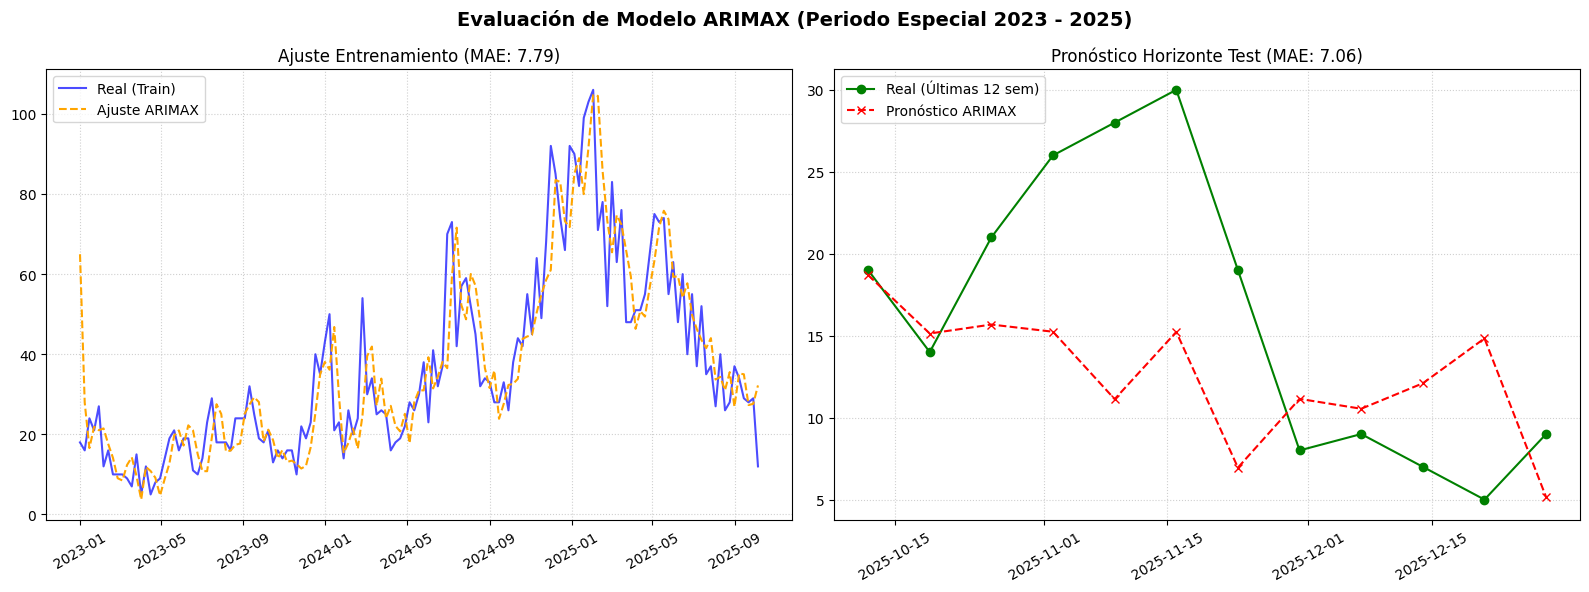

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# =============================================================================
# 1. PREPARACIÓN Y CONFIGURACIÓN DE FECHAS
# =============================================================================
# Aseguramos que el índice sea DatetimeIndex
y.index = pd.to_datetime(y.index, dayfirst=True, errors='coerce')
X_features.index = pd.to_datetime(X_features.index, dayfirst=True, errors='coerce')

# Filtramos el bloque completo de interés: Desde Enero 2023 hasta Diciembre 2025
filtro_periodo = (y.index >= '2023-01-01') & (y.index <= '2025-12-31')
y_filtrado = y[filtro_periodo].sort_index()
X_filtrado = X_features[filtro_periodo].sort_index()

# =============================================================================
# 2. SEGMENTACIÓN EN TRAIN (2023 + 2024 + 40 sem 2025) Y TEST (Últimas 12 sem)
# =============================================================================
# Usamos las últimas 12 semanas fijas para el Test
SEMANAS_TEST = 12

X_train = X_filtrado.iloc[:-SEMANAS_TEST]
y_train = y_filtrado.iloc[:-SEMANAS_TEST]

X_test = X_filtrado.iloc[-SEMANAS_TEST:]
y_test = y_filtrado.iloc[-SEMANAS_TEST:]

# Extracción de fechas para el informe informativo
fecha_init_train = y_train.index[0].strftime('%Y-%m-%d')
fecha_end_train  = y_train.index[-1].strftime('%Y-%m-%d')
fecha_init_test  = y_test.index[0].strftime('%Y-%m-%d')
fecha_end_test   = y_test.index[-1].strftime('%Y-%m-%d')

print("="*85)
print(" EJECUTANDO ENTRENAMIENTO Y TESTEO ESPECÍFICO (ARIMAX)")
print("="*85)
print(f"-> Entrenamiento (Train) : {len(y_train)} semanas | Desde {fecha_init_train} hasta {fecha_end_train}")
print(f"-> Pronóstico (Test)     : {len(y_test)} semanas | Desde {fecha_init_test} hasta {fecha_end_test}\n")

# =============================================================================
# 3. ENTRENAMIENTO DEL MODELO ARIMAX
# =============================================================================
try:
    # Instanciación del modelo ARIMAX
    modelo_arimax = SARIMAX(
        endog=y_train, 
        exog=X_train, 
        order=(1, 1, 1),              
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    # Ajuste del modelo controlando advertencias
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        modelo_ajustado = modelo_arimax.fit(maxiter=200, method='nm', disp=False)
    
    # Predicciones In-sample (Train) y Out-of-sample (Test)
    y_train_pred = modelo_ajustado.fittedvalues
    y_test_pred = modelo_ajustado.forecast(steps=len(y_test), exog=X_test)
    
    # Sincronización de índices
    y_train_pred.index = y_train.index
    y_test_pred.index = y_test.index
    
    # Cálculo de Métricas de error (MAE)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    print(f"[ÉXITO] MAE Train: {mae_train:.4f} | MAE Test: {mae_test:.4f}")
    
    # =============================================================================
    # 4. GRAFICACIÓN DE RESULTADOS
    # =============================================================================
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    fig.suptitle("Evaluación de Modelo ARIMAX (Periodo Especial 2023 - 2025)", fontsize=14, fontweight='bold')
    
    # Gráfico de Entrenamiento (Izquierda)
    axes[0].plot(y_train.index, y_train, label="Real (Train)", color="blue", alpha=0.7)
    axes[0].plot(y_train_pred.index, y_train_pred, label="Ajuste ARIMAX", color="orange", linestyle="--")
    axes[0].set_title(f"Ajuste Entrenamiento (MAE: {mae_train:.2f})")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].tick_params(axis='x', rotation=30)
    
    # Gráfico de Test / Pronóstico (Derecha)
    axes[1].plot(y_test.index, y_test, label="Real (Últimas 12 sem)", color="green", marker="o")
    axes[1].plot(y_test_pred.index, y_test_pred, label="Pronóstico ARIMAX", color="red", marker="x", linestyle="--")
    axes[1].set_title(f"Pronóstico Horizonte Test (MAE: {mae_test:.2f})")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"[ERROR] Ocurrió un fallo al entrenar o predecir con ARIMAX: {e}")